# Prompt 4B — Stepwise Tail-Aware Improvement

All results below are adaptive **Development Validation** evidence. This notebook loads saved artifacts only and performs zero fits.

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
ROOT=Path('..').resolve(); REPORTS=ROOT/'outputs/reports'; PRED=ROOT/'outputs/predictions/prompt4b/validation'; FIG=ROOT/'outputs/figures/prompt4b'; FIG.mkdir(parents=True,exist_ok=True)
comparison=pd.read_csv(REPORTS/'prompt4b_cross_stage_comparison.csv')

## 1. Prompt 4A starting point

The saved Boosting ensemble is the common Global reference.

## 2. Why Body damage is the current problem

Prompt 4A improved the upper Tail when it routed many rows, but false routes increased Body error.

## 3. Oracle ceiling

The Oracle is a diagnostic ceiling that uses targets. It is not deployable.

,mae,bottom_90_mae,top_decile_mae,top_five_percent_mae,specialist_win_fraction
0,53.881329,45.954728,125.117821,200.636196,0.09848


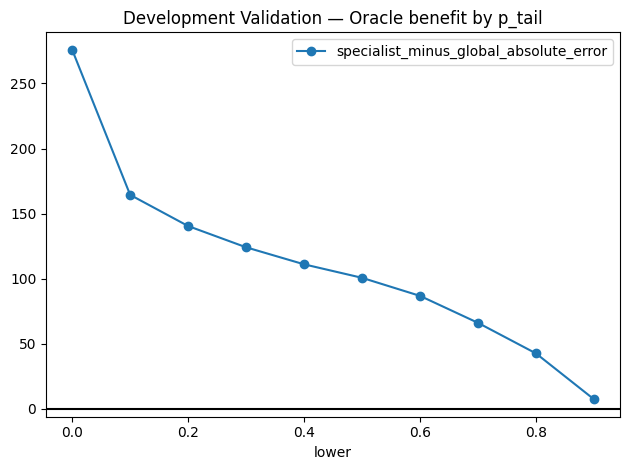

In [2]:
oracle=json.loads((REPORTS/'prompt4b_stage1_oracle.json').read_text()); display(pd.DataFrame([oracle])[['mae','bottom_90_mae','top_decile_mae','top_five_percent_mae','specialist_win_fraction']]); bins=pd.read_csv(REPORTS/'prompt4b_stage1_oracle_bins.csv'); bins.plot(x='lower',y='specialist_minus_global_absolute_error',marker='o',title='Development Validation — Oracle benefit by p_tail'); plt.axhline(0,color='black'); plt.tight_layout(); plt.savefig(FIG/'oracle_benefit_by_p_tail.png',dpi=140); plt.show()

## 4. Original Gate calibration

Reliability, Brier score, and probability-bin behavior describe the original weighted Gate.

,probability_source,scope,pr_auc,roc_auc,brier_score,calibration_error,mean_probability,observed_prevalence,platt_fit_scope
0,raw,selection,0.795170,0.968384,0.071419,0.098504,0.198247,0.099743,not_applicable
1,raw,audit,0.798393,0.968513,0.070954,0.098411,0.198145,0.099733,not_applicable
2,raw,complete_validation,0.796098,0.968421,0.071279,0.098476,0.198216,0.099740,not_applicable
3,platt,selection,0.795170,0.968384,0.039372,0.001491,0.099731,0.099743,selection_only
4,platt,audit,0.798393,0.968513,0.039225,0.003483,0.099150,0.099733,selection_only
5,platt,complete_validation,0.796098,0.968421,0.039328,0.001756,0.099557,0.099740,selection_only
6,prior_corrected,selection,0.795170,0.968384,0.039410,0.003746,0.096417,0.099743,not_applicable
7,prior_corrected,audit,0.798393,0.968513,0.039284,0.005683,0.095824,0.099733,not_applicable
8,prior_corrected,complete_validation,0.796098,0.968421,0.039372,0.004314,0.096239,0.099740,not_applicable


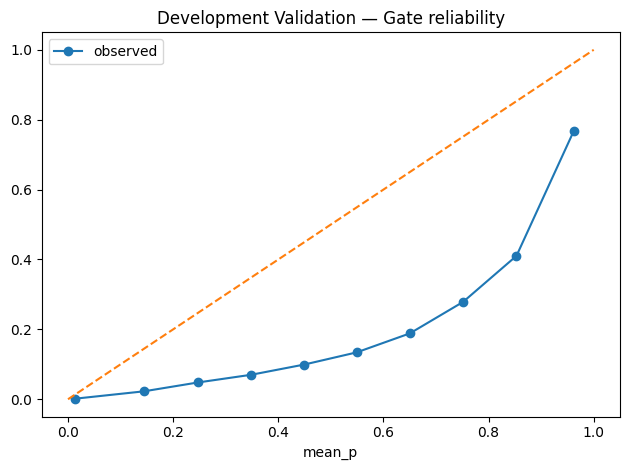

In [3]:
cal=pd.read_csv(REPORTS/'prompt4b_stage1_calibration.csv'); display(cal); rel=pd.read_parquet(PRED/'stage1_probabilities.parquet'); rel.assign(bin=pd.cut(rel.p_raw,np.linspace(0,1,11),include_lowest=True)).groupby('bin',observed=False).agg(mean_p=('p_raw','mean'),observed=('operational_tail_true','mean')).plot(x='mean_p',y='observed',marker='o',title='Development Validation — Gate reliability'); plt.plot([0,1],[0,1],'--'); plt.tight_layout(); plt.savefig(FIG/'gate_reliability.png',dpi=140); plt.show()

## 5. Prior correction

The analytical correction reverses the proven Balanced class-weight odds shift.

## 6. Platt calibration

One deterministic calibrator was fitted on the 70,000 Selection rows only.

## 7. High-confidence routing

Only probability above a declared threshold receives linearly increasing Gate strength.

## 8. Capped correction

Train-derived caps limit damage from false-positive routes.

In [4]:
s1=pd.read_csv(REPORTS/'prompt4b_stage1_candidates.csv'); display(s1.query("scope=='complete_validation'").sort_values('mae').head(10))

,candidate_id,stage,scope,probability_source,threshold,alpha,cap,capped,n_rows,mae,...,boundary_rows,operational_tail_rows,operational_body_rows,operational_tail_mae,operational_body_mae,operational_tail_signed_error,operational_body_signed_error,operational_tail_underprediction_rate,operational_body_underprediction_rate,parent_candidate_id
59,stage1_raw_t85_a50_cap50,Stage 1,complete_validation,raw,0.85,0.50,219.0,True,100000,62.225317,...,10038,9974,90026,188.341468,48.252882,-122.231922,6.111396,0.753058,0.474585,stage1_raw_t85_a50
17,stage1_raw_t85_a50,Stage 1,complete_validation,raw,0.85,0.50,NaN,False,100000,62.225541,...,10038,9974,90026,188.335204,48.253824,-122.141680,6.112339,0.753058,0.474585,NaN
62,stage1_raw_t85_a50_cap75,Stage 1,complete_validation,raw,0.85,0.50,328.5,True,100000,62.225541,...,10038,9974,90026,188.335204,48.253824,-122.141680,6.112339,0.753058,0.474585,stage1_raw_t85_a50
56,stage1_raw_t85_a50_cap25,Stage 1,complete_validation,raw,0.85,0.50,109.5,True,100000,62.225680,...,10038,9974,90026,188.404551,48.246295,-122.638917,6.104810,0.753559,0.474585,stage1_raw_t85_a50
14,stage1_raw_t85_a25,Stage 1,complete_validation,raw,0.85,0.25,NaN,False,100000,62.247449,...,10038,9974,90026,191.570422,47.919729,-130.755274,5.764372,0.772308,0.474885,NaN
68,stage1_raw_t75_a25_cap50,Stage 1,complete_validation,raw,0.75,0.25,219.0,True,100000,62.255375,...,10038,9974,90026,189.433062,48.165331,-127.907961,6.104159,0.766794,0.473885,stage1_raw_t75_a25
8,stage1_raw_t75_a25,Stage 1,complete_validation,raw,0.75,0.25,NaN,False,100000,62.255375,...,10038,9974,90026,189.433062,48.165331,-127.907961,6.104159,0.766794,0.473885,NaN
71,stage1_raw_t75_a25_cap75,Stage 1,complete_validation,raw,0.75,0.25,328.5,True,100000,62.255375,...,10038,9974,90026,189.433062,48.165331,-127.907961,6.104159,0.766794,0.473885,stage1_raw_t75_a25
65,stage1_raw_t75_a25_cap25,Stage 1,complete_validation,raw,0.75,0.25,109.5,True,100000,62.255978,...,10038,9974,90026,189.444331,48.164753,-127.960253,6.103581,0.766894,0.473885,stage1_raw_t75_a25
23,stage1_platt_t65_a50,Stage 1,complete_validation,platt,0.65,0.50,NaN,False,100000,62.260082,...,10038,9974,90026,193.535245,47.716079,-132.040445,5.536894,0.780028,0.475518,NaN


## 9. Stage 1 result

The stage champion is an experimental reference, not a project selection.

## 10. Cross-fitted Global construction

Two folds produce exactly one leakage-safe Global prediction for every Train row.

In [5]:
display(pd.DataFrame([json.loads((REPORTS/'prompt4b_stage2_crossfit.json').read_text())]).drop(columns=['fit_records','split']))

,status,rows,exactly_one_oof_per_row,zero_self_fit_rows,finite_predictions,ensemble_formula
0,PASS,400000,True,True,True,0.60*CatBoost + 0.20*LightGBM + 0.20*XGBoost


## 11. Meta-Gate design

The Meta-Gate uses 35 clean features plus the available Global prediction.

## 12. Old Gate vs Meta-Gate

Precision and recall are compared on Development Validation.

,gate,scope,threshold,pr_auc,roc_auc,brier_score,calibration_error,mean_probability,observed_prevalence,precision,recall,f1,false_negative_rate,routed_percentage
8,prompt4a_gate,complete_validation,0.50,0.796098,0.968421,0.071279,0.098476,0.198216,0.09974,0.498502,0.917385,0.645981,0.082615,0.18355
9,prompt4a_gate,complete_validation,0.65,0.796098,0.968421,0.071279,0.098476,0.198216,0.09974,0.571730,0.868659,0.689589,0.131341,0.15154
10,prompt4a_gate,complete_validation,0.75,0.796098,0.968421,0.071279,0.098476,0.198216,0.09974,0.632704,0.819330,0.714024,0.180670,0.12916
11,prompt4a_gate,complete_validation,0.85,0.796098,0.968421,0.071279,0.098476,0.198216,0.09974,0.711476,0.725386,0.718364,0.274614,0.10169
20,meta_gate,complete_validation,0.50,0.796730,0.968217,0.039188,0.001664,0.098526,0.09974,0.765965,0.645779,0.700756,0.354221,0.08409
21,meta_gate,complete_validation,0.65,0.796730,0.968217,0.039188,0.001664,0.098526,0.09974,0.843049,0.508923,0.634698,0.491077,0.06021
22,meta_gate,complete_validation,0.75,0.796730,0.968217,0.039188,0.001664,0.098526,0.09974,0.894174,0.410868,0.563028,0.589132,0.04583
23,meta_gate,complete_validation,0.85,0.796730,0.968217,0.039188,0.001664,0.098526,0.09974,0.929296,0.293864,0.446527,0.706136,0.03154


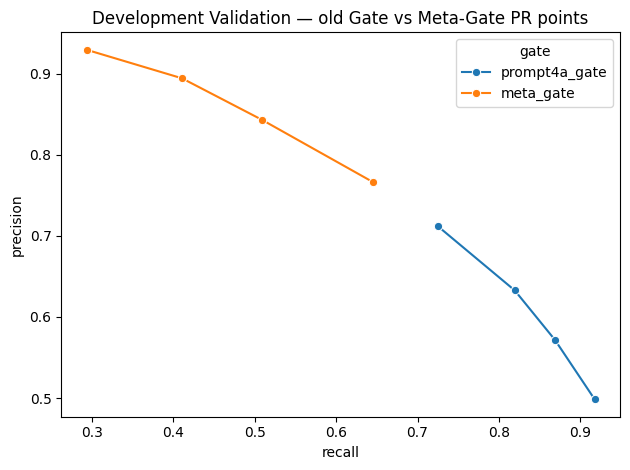

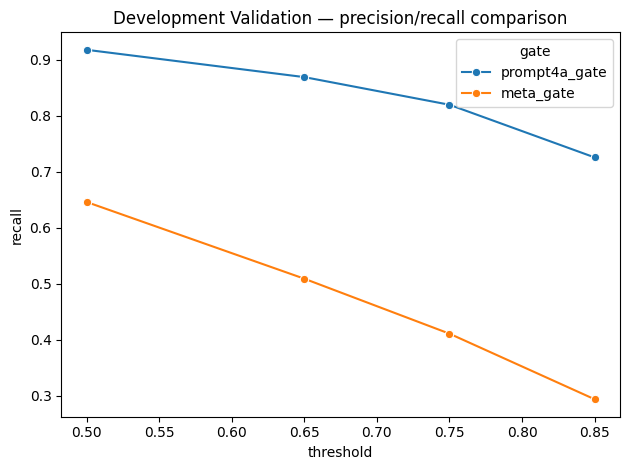

In [6]:
gate=pd.read_csv(REPORTS/'prompt4b_stage2_meta_gate_metrics.csv'); display(gate.query("scope=='complete_validation'")); sns.lineplot(data=gate.query("scope=='complete_validation'"),x='recall',y='precision',hue='gate',marker='o'); plt.title('Development Validation — old Gate vs Meta-Gate PR points'); plt.tight_layout(); plt.savefig(FIG/'old_vs_meta_pr.png',dpi=140); plt.show(); sns.lineplot(data=gate.query("scope=='complete_validation'"),x='threshold',y='recall',hue='gate',marker='o'); plt.title('Development Validation — precision/recall comparison'); plt.tight_layout(); plt.savefig(FIG/'precision_recall_comparison.png',dpi=140); plt.show()

## 13. Meta-Gate routing results

Selection ranks the predeclared uncapped and capped grid.

## 14. Stage 2 result

Audit remains descriptive and does not change the stage champion.

## 15. Residual target design

The Tail-only target is observed Train target minus cross-fitted Global prediction.

## 16. Residual Specialist diagnostics

Diagnostics show correction size, direction, and correlation.

In [7]:
res=pd.read_csv(REPORTS/'prompt4b_stage3_residual_metrics.csv'); display(res.head(20))

,grouping,group,rows,residual_mae,residual_rmse,residual_signed_error,predicted_true_residual_correlation,correct_correction_direction,p90_absolute_residual_error
0,all_operational_tail,all,9974,143.128753,288.864228,-33.212209,0.362556,0.797173,326.926789
1,target_decile,9,9974,143.128753,288.864228,-33.212209,0.362556,0.797173,326.926789
2,meta_probability_bin,0,770,58.396775,127.477472,-16.558503,0.541580,1.000000,106.596758
3,meta_probability_bin,1,648,68.034823,135.289271,-24.296296,0.632349,1.000000,136.995505
4,meta_probability_bin,2,634,66.930494,104.526965,-16.970744,0.494726,0.998423,138.393325
5,meta_probability_bin,3,692,76.792235,121.307849,-27.179388,0.491535,0.989884,183.213222
6,meta_probability_bin,4,789,85.551974,153.649072,-27.874515,0.477584,0.963245,179.127755
7,meta_probability_bin,5,907,90.048829,149.781589,-18.306476,0.402819,0.873208,184.621082
8,meta_probability_bin,6,958,107.266640,184.845022,-31.424038,0.429326,0.799582,221.289756
9,meta_probability_bin,7,1026,118.171592,188.548053,-30.683238,0.409059,0.742690,258.679538


## 17. Gated residual corrections

The Meta-Gate controls the predicted residual adjustment.

## 18. Stage 3 result

This comparison tests whether residual correction is safer than direct prediction.

## 19. Tail-aware ensemble objective

Four frozen saved predictions are combined with non-negative sum-one weights.

## 20. Tail-weighted ensemble weights

Three Selection-only weighted-MAE objectives emphasize operational Tail rows.

,candidate_id,member,weight,optimization,lambda_tail,status
0,ens_tail_weighted_l1p25,catboost,0.515180,tail_weighted_mae,1.25,COMPLETE
1,ens_tail_weighted_l1p25,lightgbm,0.159429,tail_weighted_mae,1.25,COMPLETE
2,ens_tail_weighted_l1p25,xgboost,0.223136,tail_weighted_mae,1.25,COMPLETE
3,ens_tail_weighted_l1p25,fttransformer,0.102256,tail_weighted_mae,1.25,COMPLETE
4,ens_tail_weighted_l1p5,catboost,0.537461,tail_weighted_mae,1.50,COMPLETE
5,ens_tail_weighted_l1p5,lightgbm,0.181000,tail_weighted_mae,1.50,COMPLETE
6,ens_tail_weighted_l1p5,xgboost,0.195023,tail_weighted_mae,1.50,COMPLETE
7,ens_tail_weighted_l1p5,fttransformer,0.086516,tail_weighted_mae,1.50,COMPLETE
8,ens_tail_weighted_l2p0,catboost,0.563855,tail_weighted_mae,2.00,COMPLETE
9,ens_tail_weighted_l2p0,lightgbm,0.234404,tail_weighted_mae,2.00,COMPLETE


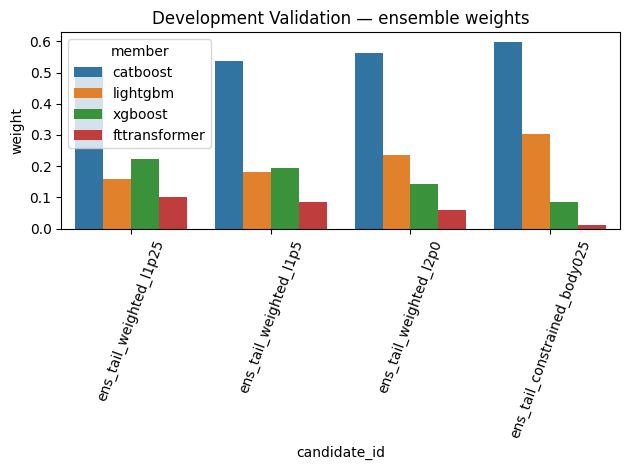

In [8]:
weights=pd.read_csv(REPORTS/'prompt4b_stage4_weights.csv'); display(weights); sns.barplot(data=weights,x='candidate_id',y='weight',hue='member'); plt.xticks(rotation=70); plt.title('Development Validation — ensemble weights'); plt.tight_layout(); plt.savefig(FIG/'ensemble_weights.png',dpi=140); plt.show()

## 21. Body-constrained ensemble

One deterministic penalty objective protects overall and Body MAE.

## 22. Stage 4 result

Static diagnostics test whether dynamic routing adds value.

## 23. Cross-stage leaderboard

This table compares the fixed Global reference and every stage champion.

,reference,candidate_id,selection_mae,audit_mae,complete_validation_mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,p85_to_p95_boundary_mae,top_decile_signed_error,top_decile_underprediction_rate,conditions_passed,provisional_status,complexity,new_model_fits_required,inference_components
0,Global reference,ens_boost_cat060,62.519519,61.975508,62.356316,125.418232,47.576966,195.178575,279.352393,98.963799,-139.054319,0.793968,0,REFERENCE,1,0,one saved ensemble
1,Prompt 4A Soft,soft_global_best_ensemble_a050,63.906354,63.545020,63.797954,124.748176,51.913643,170.602461,250.567117,86.464834,-99.799143,0.716668,4,PARTIAL,3,0,Global + old Gate + direct Specialist
2,Prompt 4A Hard,hard_global_best_single_t065,67.238669,66.707089,67.079195,129.763958,56.128486,165.493398,227.707138,113.350786,-62.013418,0.564766,3,PARTIAL,3,0,CatBoost + old Gate + direct Specialist
3,CatBoost,catboost,62.830182,62.266088,62.660954,126.795248,47.959194,194.785914,279.640881,98.157272,-137.805046,0.786478,2,PARTIAL,1,0,CatBoost
4,Stage 1 champion,stage1_raw_t85_a50_cap25,62.366821,61.896350,62.225680,124.160298,48.226291,188.038422,265.283314,101.102198,-122.373991,0.753421,5,PARTIAL,3,0,Global + old Gate + direct Specialist
5,Stage 2 champion,stage2_meta_t65_a50_cap25,62.412084,61.891912,62.256033,124.576664,47.686675,193.191092,273.864460,100.151205,-131.814235,0.780585,5,PARTIAL,3,8,Global + Meta-Gate + direct Specialist
6,Stage 3 champion,stage3_residual_t75_a75,62.352823,61.832268,62.196656,123.038499,47.669010,192.756864,272.424700,100.338601,-127.335474,0.777290,5,PARTIAL,3,10,Global + Meta-Gate + Residual Specialist
7,Stage 4 champion,ens_tail_weighted_l2p0,62.476745,61.944798,62.317161,125.662830,47.507658,195.410419,279.987708,98.816078,-140.589819,0.795566,3,PARTIAL,1,0,four-model static ensemble


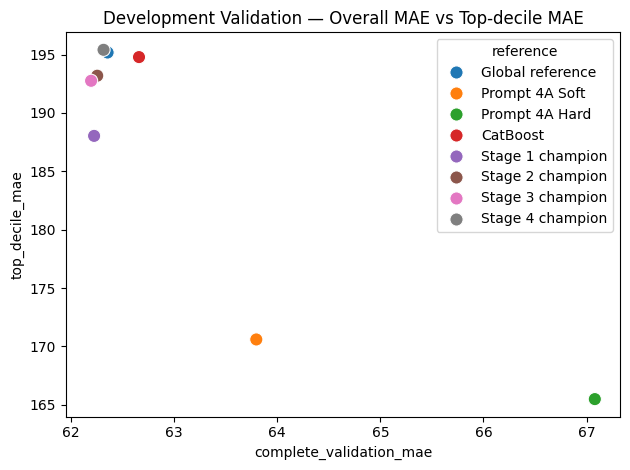

In [9]:
display(comparison); sns.scatterplot(data=comparison,x='complete_validation_mae',y='top_decile_mae',hue='reference',s=90); plt.title('Development Validation — Overall MAE vs Top-decile MAE'); plt.tight_layout(); plt.savefig(FIG/'overall_vs_topdecile.png',dpi=140); plt.show()

## 24. Body/Tail frontier

Lower-left points are better on both Body and Tail MAE.

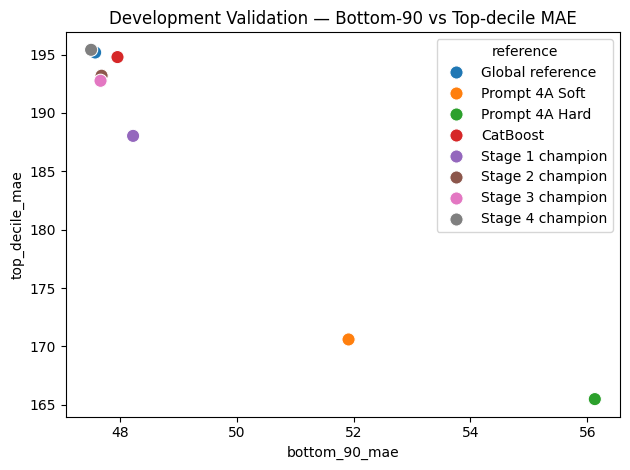

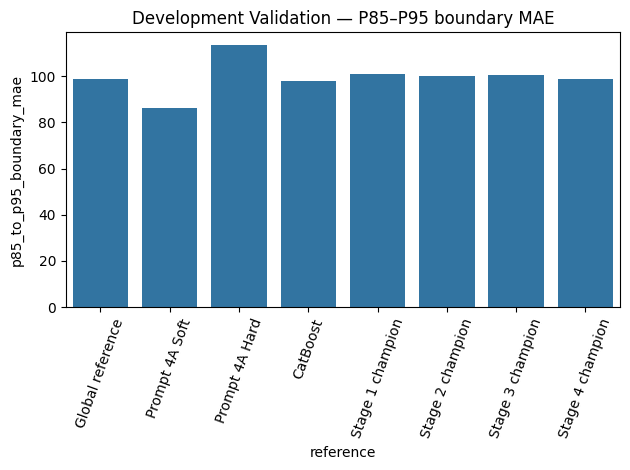

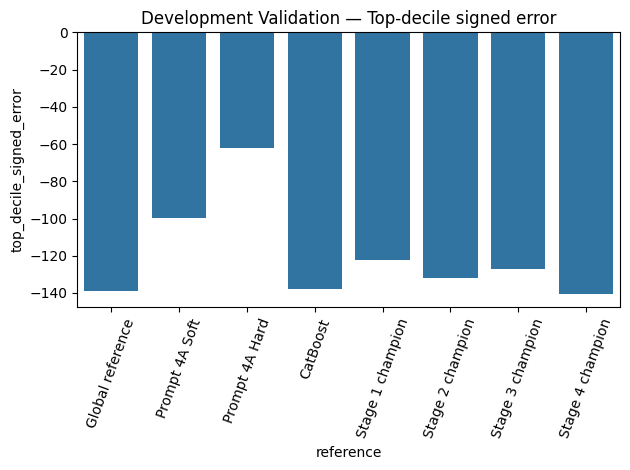

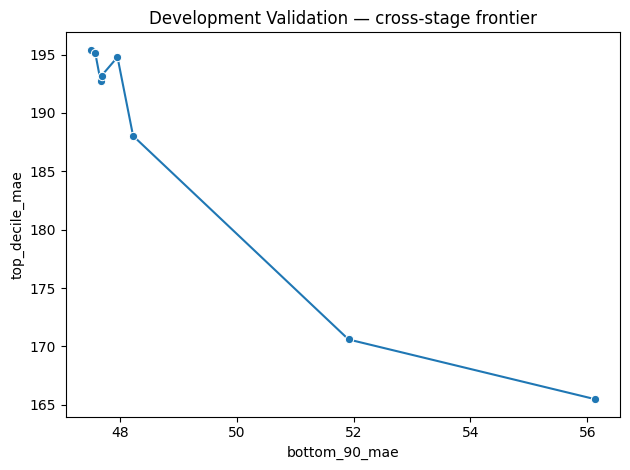

In [10]:
sns.scatterplot(data=comparison,x='bottom_90_mae',y='top_decile_mae',hue='reference',s=90); plt.title('Development Validation — Bottom-90 vs Top-decile MAE'); plt.tight_layout(); plt.savefig(FIG/'body_vs_tail.png',dpi=140); plt.show(); sns.barplot(data=comparison,x='reference',y='p85_to_p95_boundary_mae'); plt.xticks(rotation=70); plt.title('Development Validation — P85–P95 boundary MAE'); plt.tight_layout(); plt.savefig(FIG/'boundary_mae.png',dpi=140); plt.show(); sns.barplot(data=comparison,x='reference',y='top_decile_signed_error'); plt.xticks(rotation=70); plt.title('Development Validation — Top-decile signed error'); plt.tight_layout(); plt.savefig(FIG/'signed_error.png',dpi=140); plt.show(); sns.lineplot(data=comparison.sort_values('bottom_90_mae'),x='bottom_90_mae',y='top_decile_mae',marker='o'); plt.title('Development Validation — cross-stage frontier'); plt.tight_layout(); plt.savefig(FIG/'cross_stage_frontier.png',dpi=140); plt.show()

## 25. Bootstrap

Paired 500-resample intervals are descriptive adaptive Development evidence.

In [11]:
boot=json.loads((REPORTS/'prompt4b_bootstrap.json').read_text()); display(pd.DataFrame(boot['overall_mae']).T); display(pd.DataFrame(boot['fixed_complete_validation_top_decile_mae']).T)

,rows,n_resamples,seed,mae_difference,percentile_2_5,median,percentile_97_5,win_proportion
stage1_raw_t85_a50_cap25,100000.0,500.0,42.0,-0.130636,-0.191480,-0.132115,-0.067057,1.0
stage2_meta_t65_a50_cap25,100000.0,500.0,42.0,-0.100283,-0.142019,-0.099713,-0.058166,1.0
stage3_residual_t75_a75,100000.0,500.0,42.0,-0.159659,-0.230506,-0.162343,-0.088492,1.0
ens_tail_weighted_l2p0,100000.0,500.0,42.0,-0.039155,-0.057076,-0.039625,-0.023185,1.0


,rows,n_resamples,seed,mae_difference,percentile_2_5,median,percentile_97_5,win_proportion
stage1_raw_t85_a50_cap25,10013.0,500.0,42.0,-7.140153,-7.707389,-7.163478,-6.576118,1.000
stage2_meta_t65_a50_cap25,10013.0,500.0,42.0,-1.987482,-2.394138,-1.994600,-1.556025,1.000
stage3_residual_t75_a75,10013.0,500.0,42.0,-2.421711,-3.103847,-2.439178,-1.789334,1.000
ens_tail_weighted_l2p0,10013.0,500.0,42.0,0.231844,0.076843,0.230833,0.379795,0.002


## 26. Complexity comparison

Fit count and inference components show practical cost.

In [12]:
display(comparison[['reference','new_model_fits_required','inference_components','complexity']])

,reference,new_model_fits_required,inference_components,complexity
0,Global reference,0,one saved ensemble,1
1,Prompt 4A Soft,0,Global + old Gate + direct Specialist,3
2,Prompt 4A Hard,0,CatBoost + old Gate + direct Specialist,3
3,CatBoost,0,CatBoost,1
4,Stage 1 champion,0,Global + old Gate + direct Specialist,3
5,Stage 2 champion,8,Global + Meta-Gate + direct Specialist,3
6,Stage 3 champion,10,Global + Meta-Gate + Residual Specialist,3
7,Stage 4 champion,0,four-model static ensemble,1


## 27. Limitations

Audit has been reviewed adaptively, and no result is independent Test evidence.

## 28. Prompt 4C handoff

Human review is required before any later selection or freeze. No later stage is executed here.